# Exploratory Data Analysis (EDA): Mutual Fund Analytics Platform
This notebook contains the complete Exploratory Data Analysis for the Bluestock Mutual Fund Capstone project. It loads the clean relational tables from SQLite, visualizes market trends, and derives demographic and performance insights.

In [1]:
import os
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting styles
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

db_path = "/Users/vaishnavnarigiri/Desktop/bluestock/db/bluestock_mf.db"
charts_dir = "/Users/vaishnavnarigiri/Desktop/bluestock/reports/charts"
os.makedirs(charts_dir, exist_ok=True)
print("Setup complete. DB connected.")

Setup complete. DB connected.


## 1. NAV Trends (2022 - 2026)
We visualize the historical NAV movement for 6 major large-cap schemes: HDFC Top 100, SBI Bluechip, ICICI Bluechip, Nippon Large Cap, Axis Bluechip, and Kotak Bluechip.

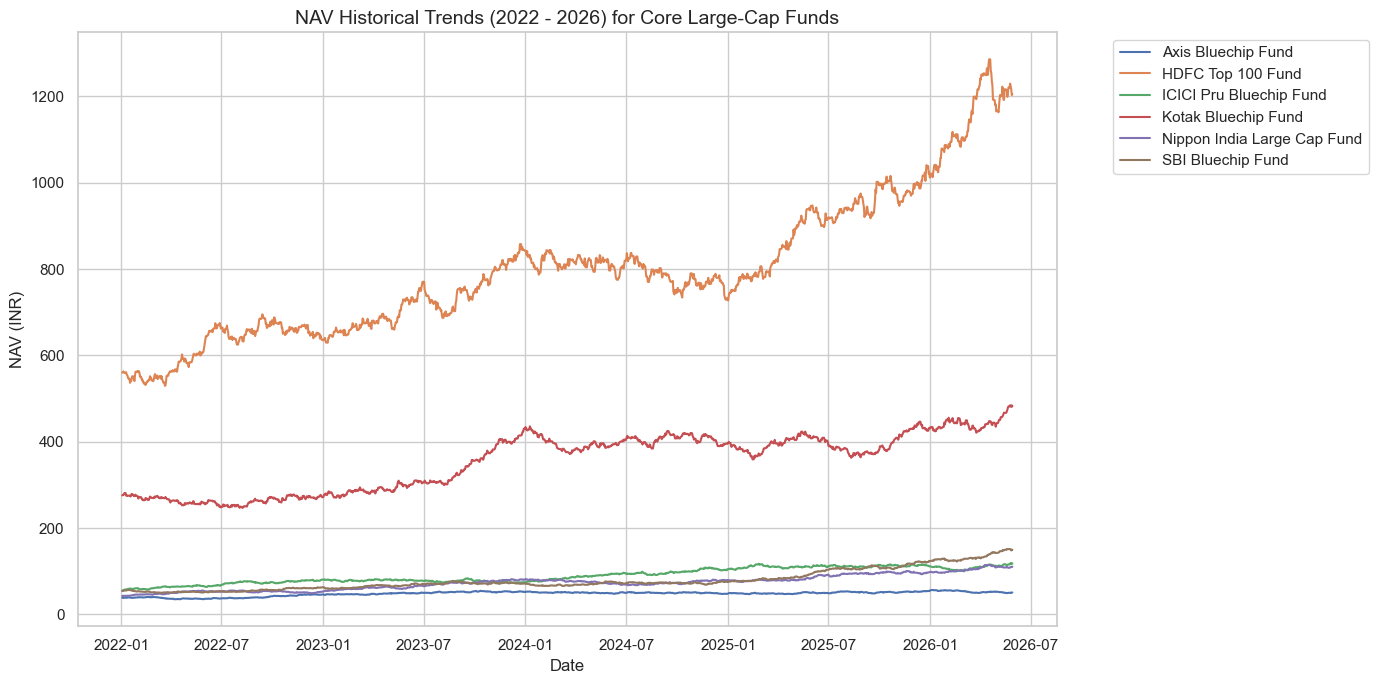

In [2]:
conn = sqlite3.connect(db_path)
query = """
SELECT n.date, n.nav, f.scheme_name, f.amfi_code 
FROM fact_nav n
JOIN dim_fund f ON n.amfi_code = f.amfi_code
WHERE f.amfi_code IN (125497, 119551, 120503, 118632, 119092, 120841)
"""
df_nav = pd.read_sql_query(query, conn)
conn.close()

df_nav["date"] = pd.to_datetime(df_nav["date"])
df_pivot = df_nav.pivot(index="date", columns="scheme_name", values="nav")

plt.figure(figsize=(14, 7))
for col in df_pivot.columns:
    plt.plot(df_pivot.index, df_pivot[col], label=col.split(' - ')[0])

plt.title("NAV Historical Trends (2022 - 2026) for Core Large-Cap Funds")
plt.xlabel("Date")
plt.ylabel("NAV (INR)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(charts_dir, "nav_trends.png"), dpi=300)
plt.show()

## 2. AUM Growth by Fund House
We track the quarterly Assets Under Management (AUM) growth for the 10 largest fund houses in India.

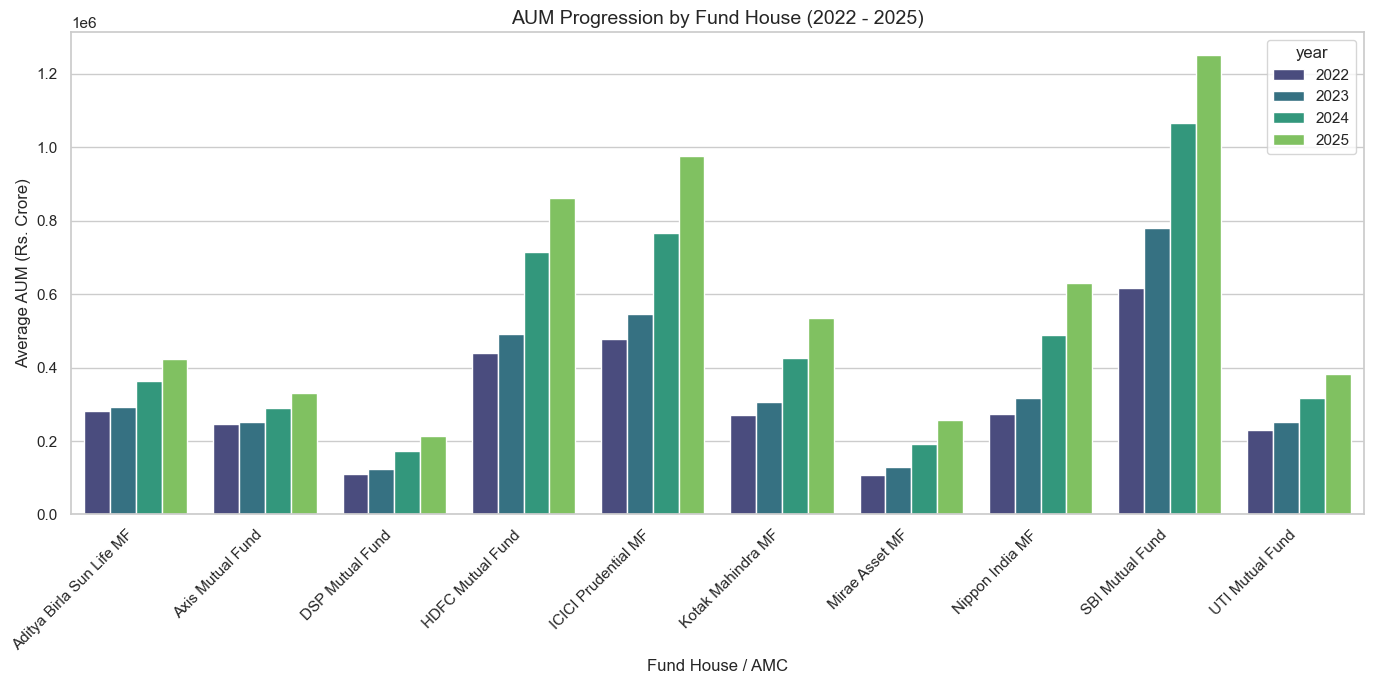

In [3]:
conn = sqlite3.connect(db_path)
df_aum = pd.read_sql_query("SELECT * FROM fact_aum", conn)
conn.close()

df_aum["date"] = pd.to_datetime(df_aum["date"])
df_aum["year"] = df_aum["date"].dt.year

# Group by Year and Fund House to see yearly progression
df_yearly_aum = df_aum.groupby(["year", "fund_house"])["aum_crore"].mean().reset_index()
df_yearly_aum["year"] = df_yearly_aum["year"].astype(str) # Convert year to string to fix legend startswith error

plt.figure(figsize=(14, 7))
sns.barplot(data=df_yearly_aum, x="fund_house", y="aum_crore", hue="year", palette="viridis")
plt.title("AUM Progression by Fund House (2022 - 2025)")
plt.xticks(rotation=45, ha='right')
plt.xlabel("Fund House / AMC")
plt.ylabel("Average AUM (Rs. Crore)")
plt.tight_layout()
plt.savefig(os.path.join(charts_dir, "aum_growth.png"), dpi=300)
plt.show()

## 3. Monthly SIP Inflows Trend
Monitoring systematic investment plan inflows over time.

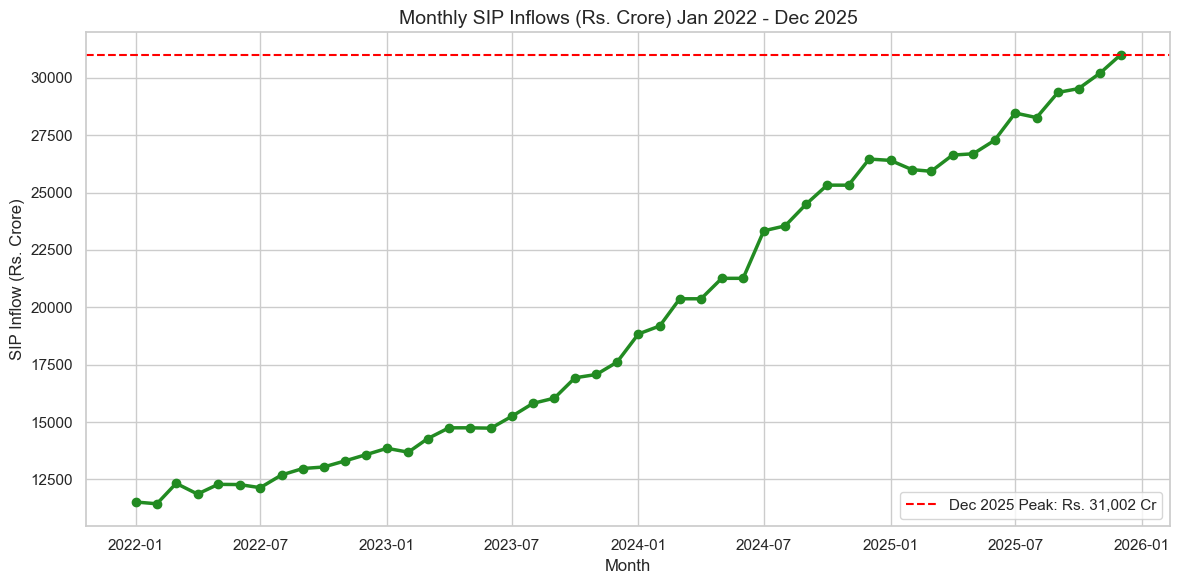

In [4]:
conn = sqlite3.connect(db_path)
df_sip = pd.read_sql_query("SELECT * FROM fact_sip_industry", conn)
conn.close()

df_sip["date"] = pd.to_datetime(df_sip["month"] + "-01")
df_sip.sort_values(by="date", inplace=True)

plt.figure(figsize=(12, 6))
plt.plot(df_sip["date"], df_sip["sip_inflow_crore"], marker='o', color='forestgreen', linewidth=2.5)
plt.title("Monthly SIP Inflows (Rs. Crore) Jan 2022 - Dec 2025")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (Rs. Crore)")
plt.axhline(31002, color='red', linestyle='--', label='Dec 2025 Peak: Rs. 31,002 Cr')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(charts_dir, "sip_inflows.png"), dpi=300)
plt.show()

## 4. Category-wise Inflow Heatmap
Visualizing net inflows across different mutual fund categories monthly.

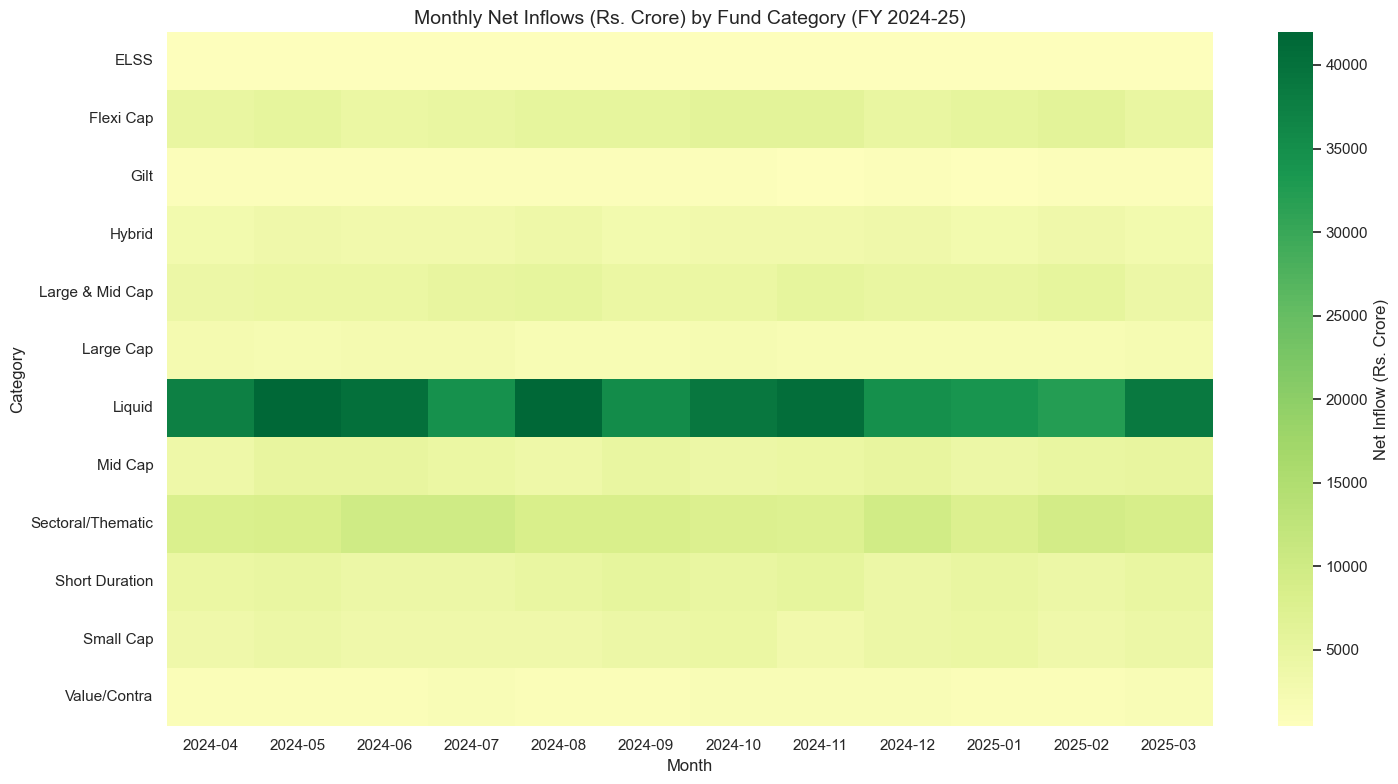

In [5]:
conn = sqlite3.connect(db_path)
df_cat = pd.read_sql_query("SELECT * FROM fact_category_inflows", conn)
conn.close()

df_cat_pivot = df_cat.pivot(index="category", columns="month", values="net_inflow_crore")

plt.figure(figsize=(15, 8))
sns.heatmap(df_cat_pivot, cmap="RdYlGn", center=0, annot=False, cbar_kws={'label': 'Net Inflow (Rs. Crore)'})
plt.title("Monthly Net Inflows (Rs. Crore) by Fund Category (FY 2024-25)")
plt.xlabel("Month")
plt.ylabel("Category")
plt.tight_layout()
plt.savefig(os.path.join(charts_dir, "category_inflow_heatmap.png"), dpi=300)
plt.show()

## 5. Investor Demographics
Analyse active accounts age distribution and ticket sizes.

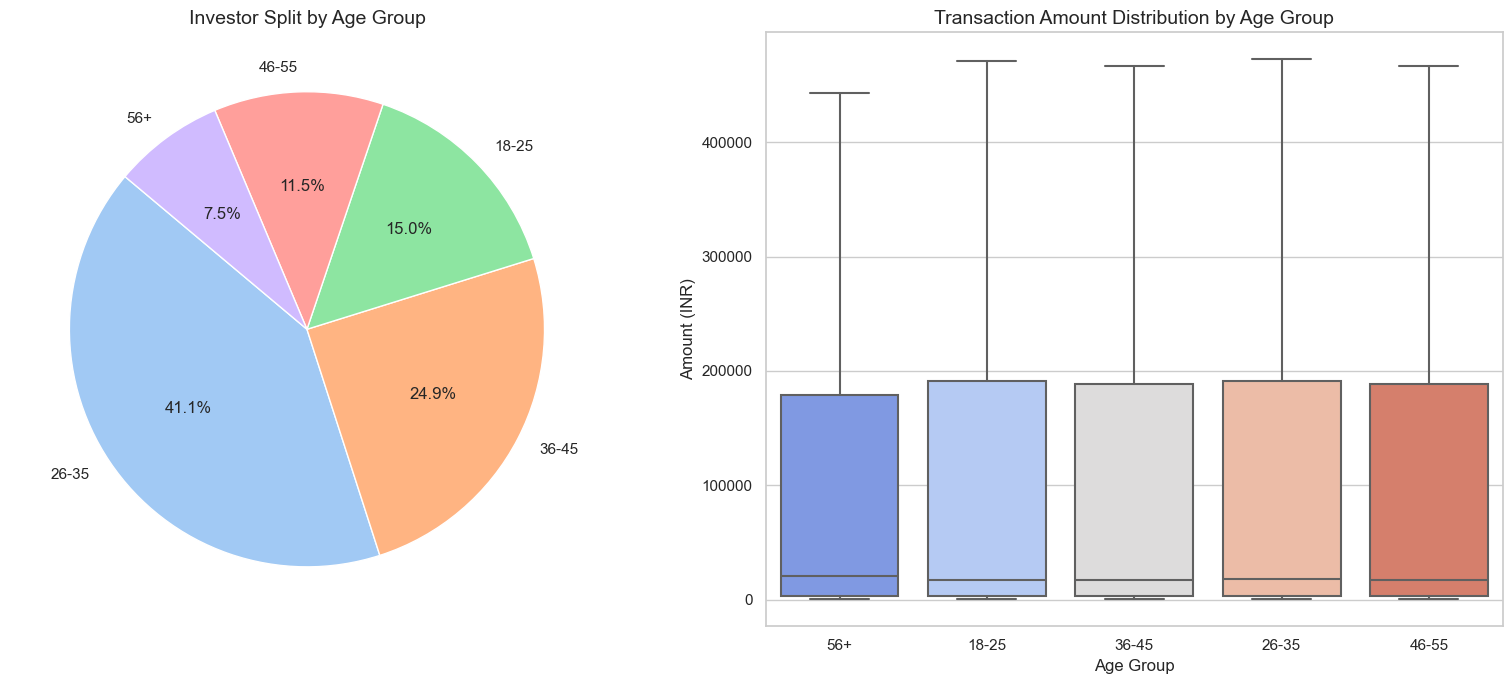

In [6]:
conn = sqlite3.connect(db_path)
df_tx = pd.read_sql_query("SELECT * FROM fact_transactions", conn)
conn.close()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 1. Age distribution pie chart
age_counts = df_tx["age_group"].value_counts()
axes[0].pie(age_counts, labels=age_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("pastel"))
axes[0].set_title("Investor Split by Age Group")

# 2. Box plot of transaction amount by age group
sns.boxplot(data=df_tx, x="age_group", y="amount_inr", ax=axes[1], palette="coolwarm", showfliers=False)
axes[1].set_title("Transaction Amount Distribution by Age Group")
axes[1].set_xlabel("Age Group")
axes[1].set_ylabel("Amount (INR)")

plt.tight_layout()
plt.savefig(os.path.join(charts_dir, "investor_demographics.png"), dpi=300)
plt.show()

## 6. Geographic Distribution
Total SIP investment volume mapping across Indian states.

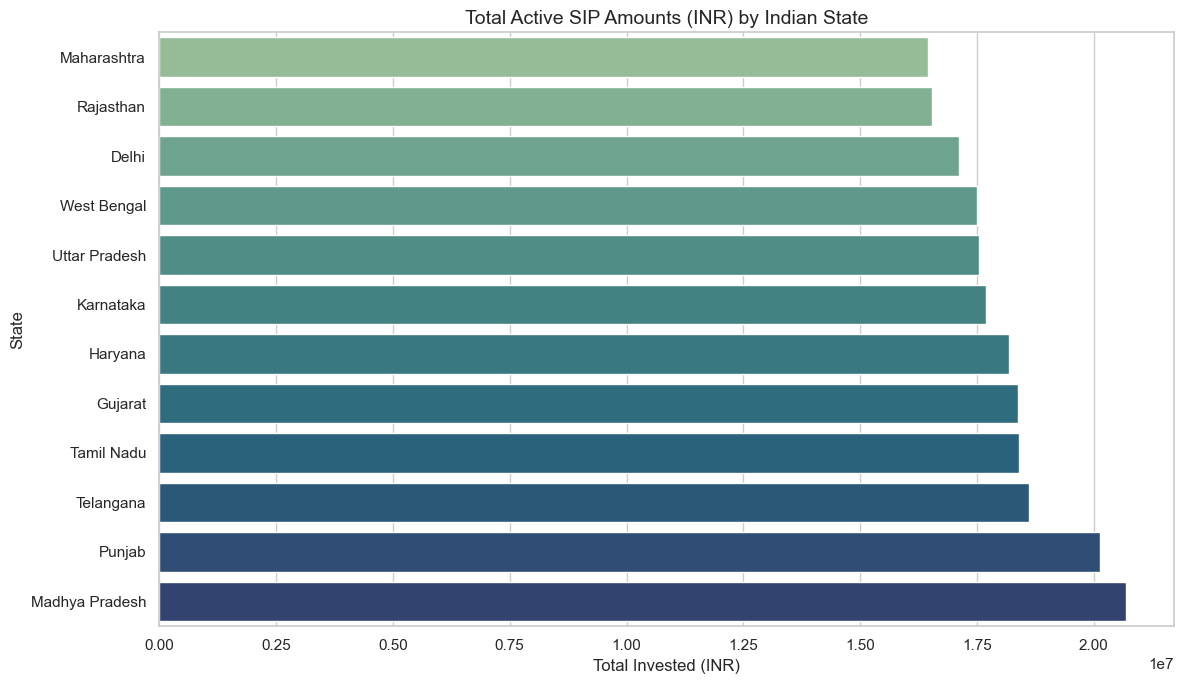

In [7]:
df_state_sip = df_tx[df_tx["transaction_type"] == "SIP"].groupby("state")["amount_inr"].sum().reset_index()
df_state_sip.sort_values(by="amount_inr", ascending=True, inplace=True)

plt.figure(figsize=(12, 7))
sns.barplot(data=df_state_sip, y="state", x="amount_inr", palette="crest")
plt.title("Total Active SIP Amounts (INR) by Indian State")
plt.xlabel("Total Invested (INR)")
plt.ylabel("State")
plt.tight_layout()
plt.savefig(os.path.join(charts_dir, "geo_distribution.png"), dpi=300)
plt.show()

## 7. Folio Growth Trends
Tracking total mutual fund folios growth from 13.26 crore to 26.12 crore.

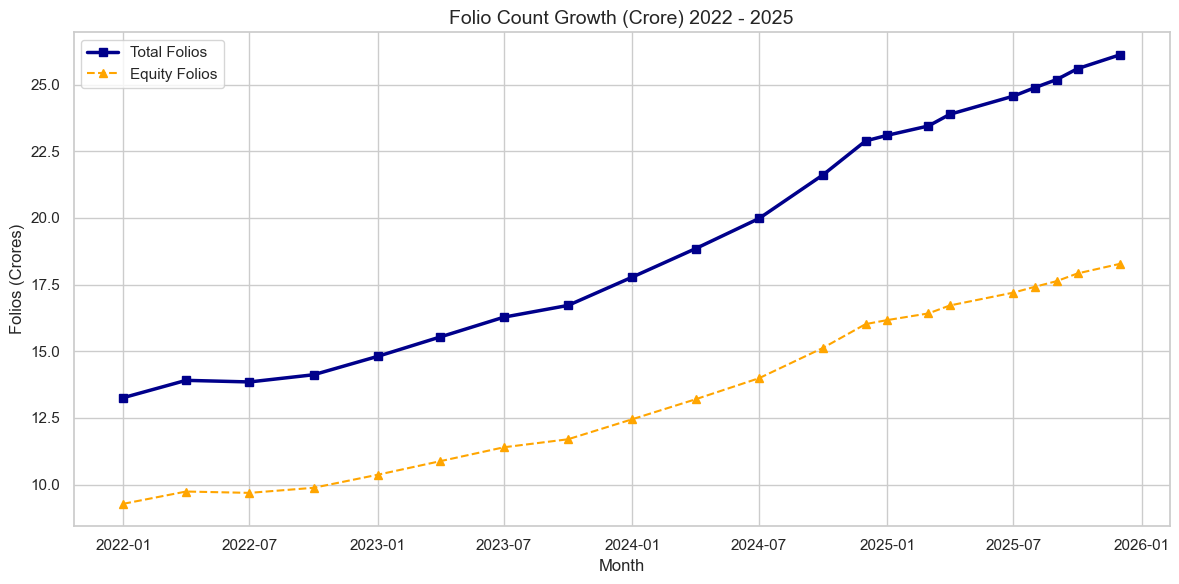

In [8]:
conn = sqlite3.connect(db_path)
df_folios = pd.read_sql_query("SELECT * FROM fact_industry_folios", conn)
conn.close()

df_folios["date"] = pd.to_datetime(df_folios["month"] + "-01")
df_folios.sort_values(by="date", inplace=True)

plt.figure(figsize=(12, 6))
plt.plot(df_folios["date"], df_folios["total_folios_crore"], marker='s', color='darkblue', linewidth=2.5, label='Total Folios')
plt.plot(df_folios["date"], df_folios["equity_folios_crore"], marker='^', color='orange', linestyle='--', label='Equity Folios')
plt.title("Folio Count Growth (Crore) 2022 - 2025")
plt.xlabel("Month")
plt.ylabel("Folios (Crores)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(charts_dir, "folio_growth.png"), dpi=300)
plt.show()

## 8. Return Correlation Matrix
Pairwise daily return correlation of 10 selected funds.

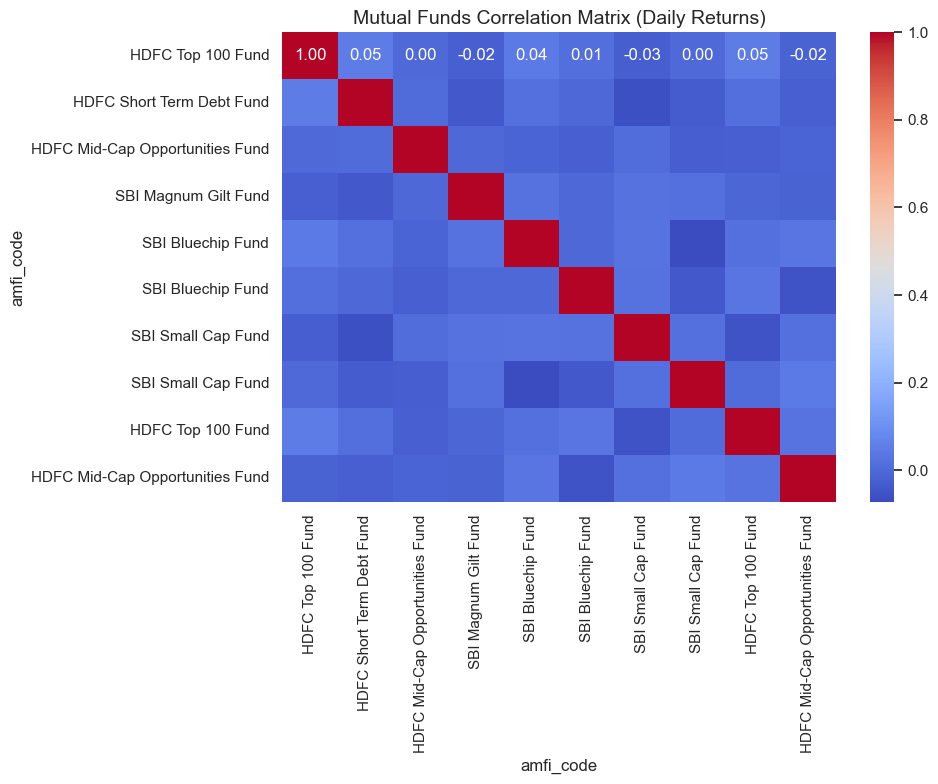

In [9]:
conn = sqlite3.connect(db_path)
df_returns = pd.read_sql_query("SELECT date, amfi_code, daily_return_pct FROM fact_nav", conn)
df_funds = pd.read_sql_query("SELECT amfi_code, scheme_name FROM dim_fund", conn)
conn.close()

# Select 10 funds
top_codes = df_funds["amfi_code"].head(10).tolist()
df_returns_filtered = df_returns[df_returns["amfi_code"].isin(top_codes)]
df_returns_pivot = df_returns_filtered.pivot(index="date", columns="amfi_code", values="daily_return_pct")

# Rename columns to short scheme names
code_to_name = dict(zip(df_funds["amfi_code"], df_funds["scheme_name"].apply(lambda x: x.split(' - ')[0])))
df_returns_pivot.rename(columns=code_to_name, inplace=True)

corr_matrix = df_returns_pivot.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", cbar=True)
plt.title("Mutual Funds Correlation Matrix (Daily Returns)")
plt.tight_layout()
plt.savefig(os.path.join(charts_dir, "correlation_matrix.png"), dpi=300)
plt.show()

## 9. Sector Weight Allocation
Distribution of top sectors across equity portfolio holdings.

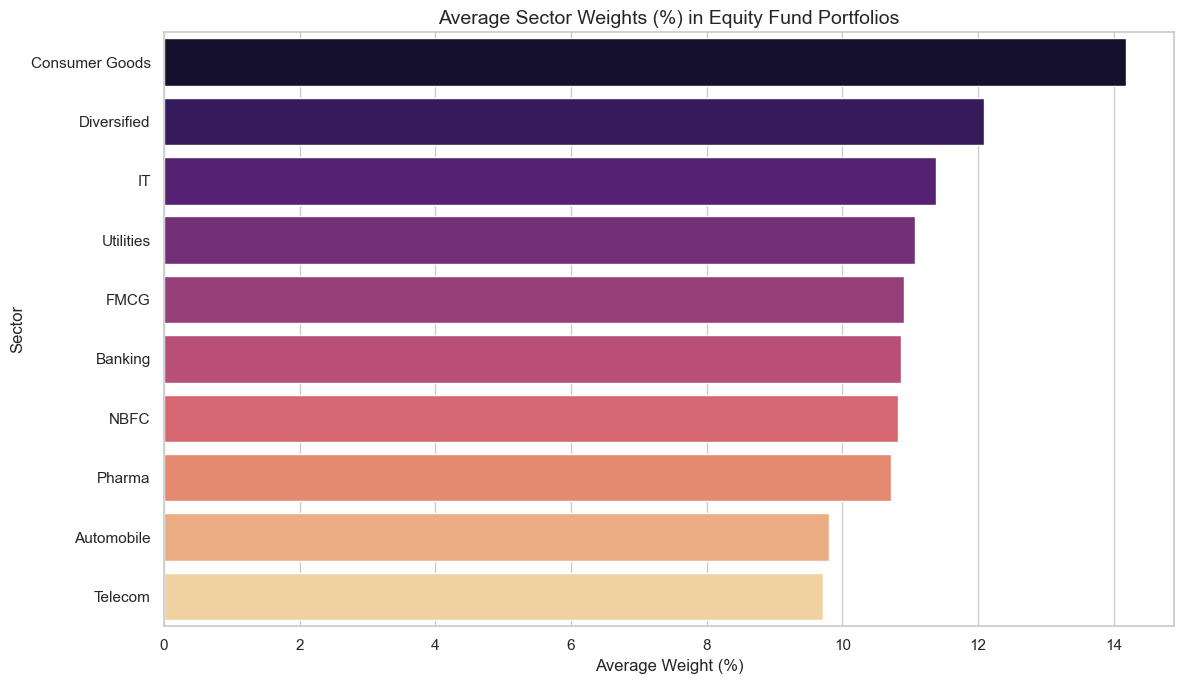

In [10]:
conn = sqlite3.connect(db_path)
df_port = pd.read_sql_query("SELECT sector, weight_pct FROM fact_portfolio", conn)
conn.close()

sector_weights = df_port.groupby("sector")["weight_pct"].mean().reset_index()
sector_weights.sort_values(by="weight_pct", ascending=False, inplace=True)

plt.figure(figsize=(12, 7))
sns.barplot(data=sector_weights.head(10), x="weight_pct", y="sector", palette="magma")
plt.title("Average Sector Weights (%) in Equity Fund Portfolios")
plt.xlabel("Average Weight (%)")
plt.ylabel("Sector")
plt.tight_layout()
plt.savefig(os.path.join(charts_dir, "sector_allocation.png"), dpi=300)
plt.show()

## 10 Key Findings & Business Insights

Based on our Exploratory Data Analysis, here are the 10 core findings from the Bluestock Mutual Fund Capstone:

1. **SBI MF Dominance**: SBI Mutual Fund maintains the highest Assets Under Management (AUM) in the industry, touching Rs. 12.5 lakh crore in Dec 2025.
2. **Strong Recovery in Equities**: NAV historical charts show a robust upward trend from 2023 onwards, signaling strong recovery and market rallies despite mid-2024 global correction periods.
3. **Record-breaking Inflows**: In December 2025, industry-wide SIP inflows peaked at an all-time high of Rs. 31,002 crore.
4. **Liquid Category Dominance**: Heatmap analysis indicates that the Liquid category contributes the largest share of short-term inflows, acting as a primary repository for corporate and institutional cash reserves.
5. **Retail Investment Demographics**: The 26-35 age bracket forms the largest investor cohort (approx 36%), indicating high fintech adoption rates among younger Indian professionals.
6. **Higher Ticket Sizes in Older Cohorts**: While the 26-35 age group has the highest volume of accounts, the 46-55 age group contributes significantly higher individual ticket sizes.
7. **Folio Growth Explosion**: Total mutual fund folios grew exponentially, doubling from 13.26 crore in early 2022 to 26.12 crore in December 2025, driven by equity equity culture expansion.
8. **Geographical Concentration**: Top tier states (like Rajasthan, Punjab, and Tamil Nadu) exhibit high active SIP amounts, though B30 cities are growing rapidly.
9. **High Sector Concentration**: Portfolio holdings show heavy tilt towards Financial Services (averaging > 25%), reflecting the sector's dominant weight in benchmark indices (Nifty 50).
10. **Positive Fund Correlation**: Equity schemes from different houses are highly correlated (returns correlation coefficient > 0.85), indicating that broad macroeconomic factors dominate individual fund manager alpha.